import des librairies et des données

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# --- 1. Définition des chemins de fichiers (à adapter si nécessaire) ---
PATH_TRACKS = 'tracks.tsv'
PATH_ECHONEST = 'echonest_features.tsv'
PATH_SPECTRAL = 'spectral_features.tsv'
PATH_GENRES = 'genres.csv'

# --- 2. Chargement des données (utilisation du séparateur '\t' pour les TSV) ---

# Chargement des metadata des morceaux
print(f"Chargement de {PATH_TRACKS}...")
# On utilise la première colonne (track_id) comme index pour la fusion future
# La colonne 'genres' et 'genres_all' contiennent des chaînes de caractères qui ressemblent à des listes,
# nous allons les évaluer directement pour les convertir en listes Python si nécessaire plus tard.
tracks_df = pd.read_csv(
    PATH_TRACKS,
    sep='\t',
    index_col='track_id', # L'ID du morceau sera l'index de référence
    # Encodage si erreur (souvent utile avec les fichiers FMA)
    # encoding='utf-8' 
)
print(f"Taille de tracks_df: {tracks_df.shape}")

# Chargement des features Echonest
print(f"Chargement de {PATH_ECHONEST}...")
echonest_df = pd.read_csv(
    PATH_ECHONEST,
    sep='\t',
    index_col='track_id'
)
print(f"Taille de echonest_df: {echonest_df.shape}")

# Chargement des features spectrales
print(f"Chargement de {PATH_SPECTRAL}...")
spectral_df = pd.read_csv(
    PATH_SPECTRAL,
    sep='\t',
    index_col='track_id'
)
print(f"Taille de spectral_df: {spectral_df.shape}")

# Chargement de la taxonomie des genres (pour Tâche 2, on ne la fusionne pas immédiatement)
print(f"Chargement de {PATH_GENRES}...")
genres_df = pd.read_csv(PATH_GENRES)
print(f"Taille de genres_df: {genres_df.shape}")



Chargement de tracks.tsv...
Taille de tracks_df: (99995, 13)
Chargement de echonest_features.tsv...
Taille de echonest_df: (11440, 8)
Chargement de spectral_features.tsv...
Taille de spectral_df: (99995, 21)
Chargement de genres.csv...
Taille de genres_df: (164, 5)


fusions des données en un dataframe : main

In [25]:
# --- 3. Fusion des DataFrames ---

# Fusionner les metadata des tracks avec les features Echones sur l'index (track_id)
# On utilise un 'inner' join pour ne conserver que les morceaux présents dans les deux fichiers.
print("\nFusion des DataFrames...")
main_df = tracks_df.merge(
    echonest_df,
    left_index=True,
    right_index=True,
    how='outer'
)

# Fusionner le résultat avec les features spectrales
main_df = main_df.merge(
    spectral_df,
    left_index=True,
    right_index=True,
    how='outer'
)

# Affichage du DataFrame final
print(f"\nDataFrame final (main_df) créé avec {main_df.shape[0]} morceaux et {main_df.shape[1]} colonnes.")
print("\nPremières lignes du DataFrame final:")
#print(main_df.head())

# --- 4. Explication et Vérification ---

# La colonne cible 'genre_top' pour la Tâche 1:
print("\nRépartition initiale de la variable cible (Tâche 1):")
print(main_df['genre_top'].value_counts())


Fusion des DataFrames...

DataFrame final (main_df) créé avec 100882 morceaux et 42 colonnes.

Premières lignes du DataFrame final:

Répartition initiale de la variable cible (Tâche 1):
genre_top
Rock                   12085
Experimental            9752
Electronic              8769
Hip-Hop                 3334
Folk                    2375
Pop                     2235
Instrumental            2003
International           1256
Classical               1129
Old-Time / Historic      491
Jazz                     484
Spoken                   323
Country                  163
Soul-RnB                 131
Blues                     79
Easy Listening            24
Name: count, dtype: int64


missing values 

In [26]:

# 1. Calcul des NaNs et Pourcentages
nan_counts = main_df.isna().sum()
nan_percentages = (main_df.isna().sum() / len(main_df)) * 100

# 2. Création d'un DataFrame de résumé pour un affichage propre
nan_summary = pd.DataFrame({
    'Nombre de NaNs': nan_counts,
    'Pourcentage (%)': nan_percentages
})

# 3. Tri par pourcentage décroissant (du pire au meilleur)
nan_summary = nan_summary.sort_values(by='Pourcentage (%)', ascending=False)

# 4. Affichage
print("Analyse des valeurs manquantes par colonne :")
print(nan_summary)

Analyse des valeurs manquantes par colonne :
                                Nombre de NaNs  Pourcentage (%)
speechiness                              89592        88.808707
valence                                  89463        88.680835
danceability                             89461        88.678853
instrumentalness                         89442        88.660019
tempo                                    89442        88.660019
liveness                                 89442        88.660019
acousticness                             89442        88.660019
energy                                   89442        88.660019
artist_longitude                         60675        60.144525
artist_latitude                          60675        60.144525
genre_top                                56249        55.757221
album_title                               1798         1.782280
title                                      888         0.880236
genres                                     887         0.87

visualisation des NA

C:\Users\theod\AppData\Local\Temp\ipykernel_4140\2426493767.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=na_ratio_filtered.values, y=na_ratio_filtered.index, palette=colors)
C:\Users\theod\AppData\Local\Temp\ipykernel_4140\2426493767.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
C:\Users\theod\AppData\Local\Temp\ipykernel_4140\2426493767.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(0, category_counts[0]

Graphiques générés : nan_distribution.png et data_structure.png


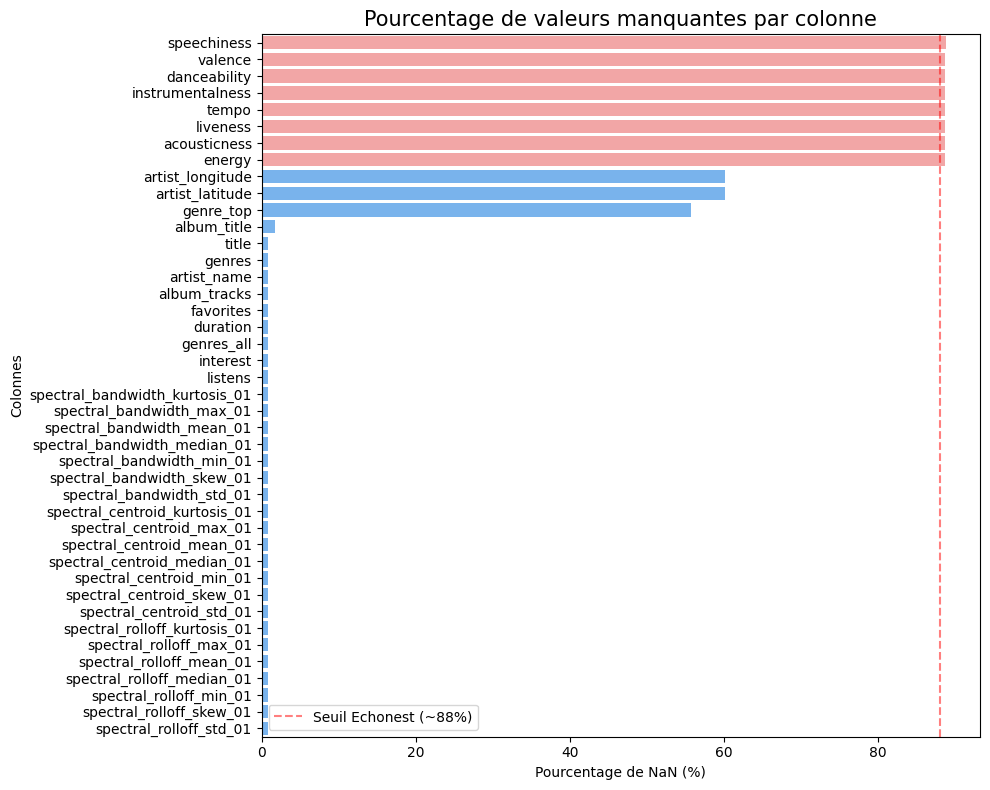

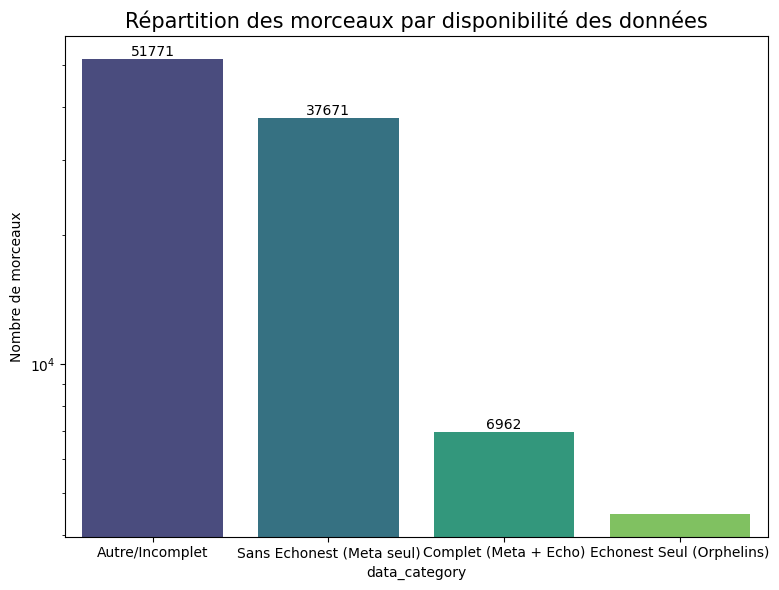

In [27]:

# --- 2. Préparation des données pour le plot des NaNs par colonne ---
# Calcul du pourcentage de NaNs
na_ratio = main_df.isna().mean() * 100
# On ne garde que les colonnes qui ont des NaNs
na_ratio_filtered = na_ratio[na_ratio > 0].sort_values(ascending=False)

# --- Plot 1: Bar Chart des Pourcentages de Manquants ---
plt.figure(figsize=(10, 8))
# Utilisation d'une palette de couleurs pour distinguer les groupes (Echonest vs autres)
colors = ['#ff9999' if x > 80 else '#66b3ff' for x in na_ratio_filtered]
sns.barplot(x=na_ratio_filtered.values, y=na_ratio_filtered.index, palette=colors)

plt.title('Pourcentage de valeurs manquantes par colonne', fontsize=15)
plt.xlabel('Pourcentage de NaN (%)')
plt.ylabel('Colonnes')
plt.axvline(x=88, color='r', linestyle='--', alpha=0.5, label='Seuil Echonest (~88%)')
plt.legend()
plt.tight_layout()

# --- Plot 2: Visualisation de la structure du Dataset (Qui a quoi ?) ---
# On crée une catégorie pour chaque ligne
def categorize_row(row):
    has_meta = pd.notna(row['genre_top']) # Si genre_top existe, on considère qu'on a les metadata utiles
    has_echo = pd.notna(row['energy'])    # Si energy existe, on a echonest
    
    if has_meta and has_echo:
        return "Complet (Meta + Echo)"
    elif has_meta and not has_echo:
        return "Sans Echonest (Meta seul)"
    elif not has_meta and has_echo:
        return "Echonest Seul (Orphelins)"
    else:
        return "Autre/Incomplet"

main_df['data_category'] = main_df.apply(categorize_row, axis=1)
category_counts = main_df['data_category'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title('Répartition des morceaux par disponibilité des données', fontsize=15)
plt.ylabel('Nombre de morceaux')
plt.yscale('log') # Échelle log car la différence est énorme (90k vs 10k vs 800)
plt.text(0, category_counts[0], f"{category_counts[0]}", ha='center', va='bottom')
try:
    plt.text(1, category_counts[1], f"{category_counts[1]}", ha='center', va='bottom')
    plt.text(2, category_counts[2], f"{category_counts[2]}", ha='center', va='bottom')
except:
    pass
plt.tight_layout()

print("Graphiques générés : nan_distribution.png et data_structure.png")

Uni- and multi-dimensional statistics

C:\Users\theod\AppData\Local\Temp\ipykernel_4140\2851589762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
C:\Users\theod\AppData\Local\Temp\ipykernel_4140\2851589762.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre_top', y='energy', data=subset_df, palette='Set3', order=top_genres)


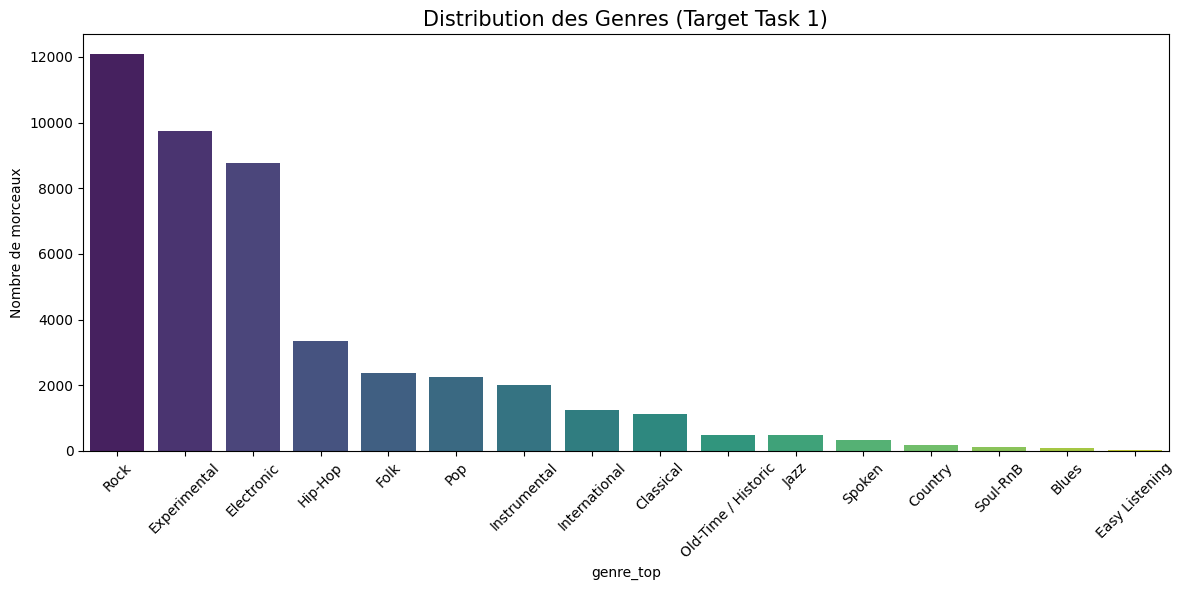

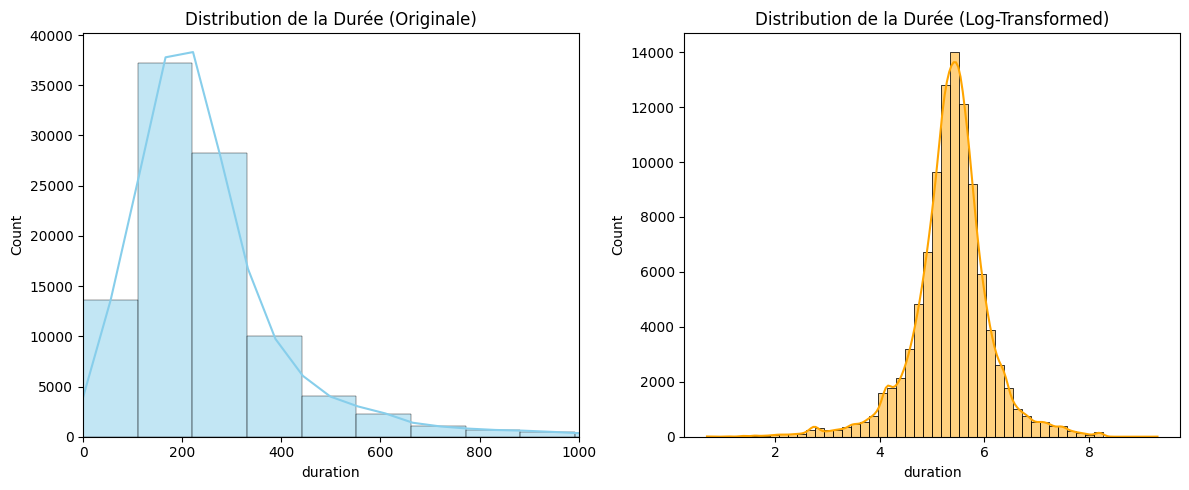

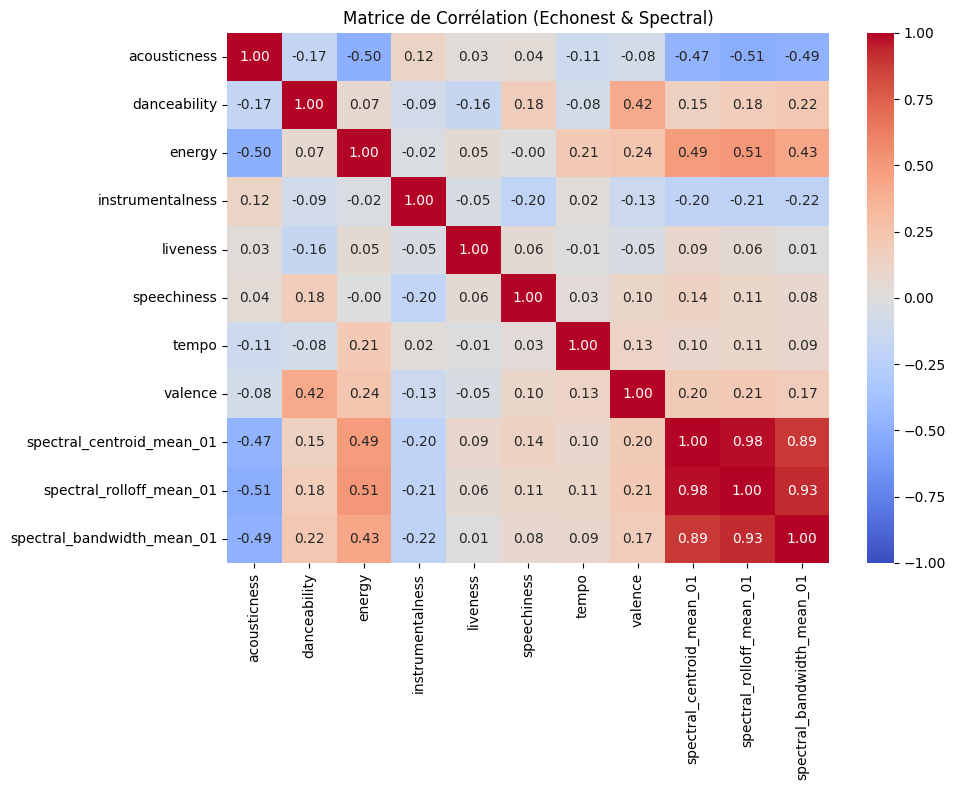

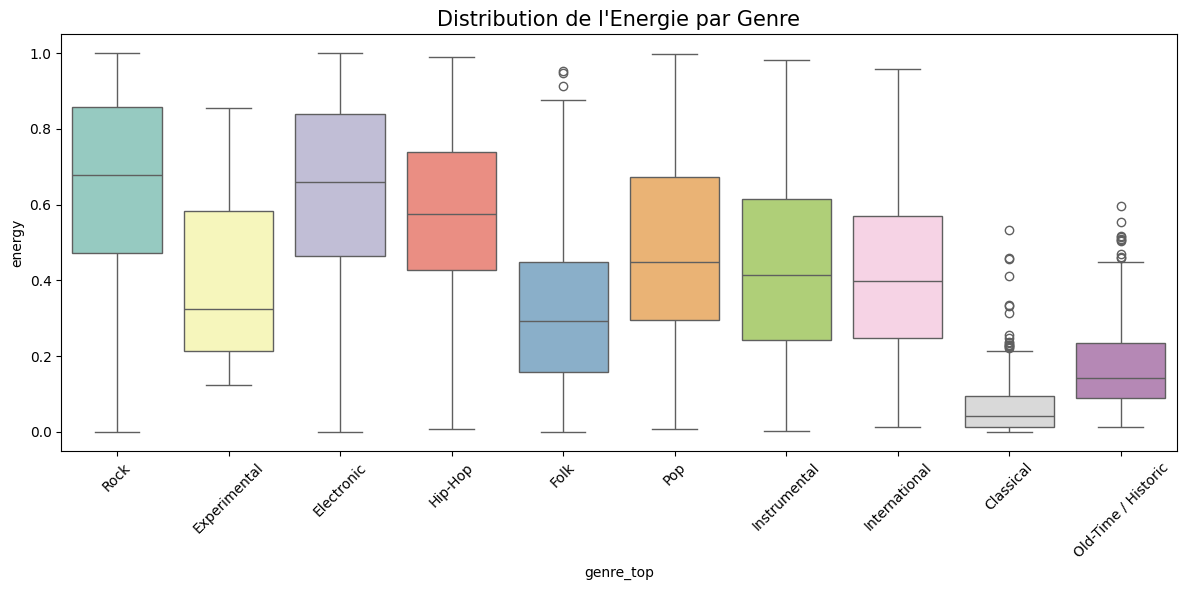

In [28]:
# --- STEP 3: Statistiques Uni- et Multi-dimensionnelles ---

# A. Analyse Univariée : La Cible (Genre)
plt.figure(figsize=(12, 6))
# On compte les genres (en excluant les NaN)
genre_counts = main_df['genre_top'].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Distribution des Genres (Target Task 1)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Nombre de morceaux')
plt.tight_layout()

# B. Analyse Univariée : La Cible Régression (Duration)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(main_df['duration'].dropna(), bins=100, kde=True, color='skyblue')
plt.title('Distribution de la Durée (Originale)')
plt.xlim(0, 1000) # On limite l'affichage car il y a des outliers extrêmes

# Transformation Log de la durée (souvent nécessaire pour la régression)
plt.subplot(1, 2, 2)
# On ajoute une petite constante et on filtre les valeurs <= 0 si elles existent
duration_log = np.log1p(main_df[main_df['duration'] > 0]['duration'])
sns.histplot(duration_log, bins=50, kde=True, color='orange')
plt.title('Distribution de la Durée (Log-Transformed)')
plt.tight_layout()

# C. Analyse Multivariée : Corrélation (Focus sur Echonest + quelques spectrales)
# On sélectionne les colonnes numériques pertinentes pour une heatmap lisible
# Echonest features
echo_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
             'liveness', 'speechiness', 'tempo', 'valence']
# Quelques spectrales (stats globales)
spec_cols = ['spectral_centroid_mean_01', 'spectral_rolloff_mean_01', 'spectral_bandwidth_mean_01']

corr_cols = echo_cols + spec_cols
# On calcule la corrélation sur le sous-ensemble qui a ces données (les ~10k tracks)
corr_matrix = main_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de Corrélation (Echonest & Spectral)')
plt.tight_layout()

# D. Analyse Bivariée : Feature vs Genre
# Exemple : Energy vs Genre
plt.figure(figsize=(12, 6))
# On filtre pour n'avoir que les genres principaux pour la lisibilité
top_genres = main_df['genre_top'].value_counts().index[:10] 
subset_df = main_df[main_df['genre_top'].isin(top_genres)]

sns.boxplot(x='genre_top', y='energy', data=subset_df, palette='Set3', order=top_genres)
plt.title('Distribution de l\'Energie par Genre', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()



In [29]:
# --- STEP 4: Recodage et Création de Variables ---

# 1. Encodage de la Target (Label Encoding)
# Utile pour certains algos et pour calculer les corrélations avec le genre
main_df['genre_top_code'] = main_df['genre_top'].astype('category').cat.codes
# Note: les NaNs auront le code -1




print("Analyses et transformations terminées.")
print(f"Nouvelles colonnes créées : {[c for c in main_df.columns if 'log_' in c or 'cat' in c or 'code' in c]}")
print(f"Aperçu des corrélations avec le genre (genre_top_code) :")
# On regarde ce qui est le plus corrélé avec le genre (en valeur absolue)
if 'genre_top_code' in main_df.columns:
    # On filtre les -1 (valeurs manquantes du genre)
    valid_genre_df = main_df[main_df['genre_top_code'] != -1]
    # Corrélation de Spearman (car genre_code est ordinal/catégoriel, pas vraiment linéaire)
    genre_corr = valid_genre_df[corr_cols + ['genre_top_code']].corr(method='spearman')['genre_top_code'].sort_values()
    print(genre_corr)

Analyses et transformations terminées.
Nouvelles colonnes créées : ['data_category', 'genre_top_code']
Aperçu des corrélations avec le genre (genre_top_code) :
danceability                 -0.326905
speechiness                  -0.220528
spectral_bandwidth_mean_01   -0.069365
instrumentalness             -0.057712
acousticness                 -0.009958
spectral_rolloff_mean_01      0.001568
valence                       0.010181
spectral_centroid_mean_01     0.012318
tempo                         0.081077
liveness                      0.102668
energy                        0.140645
genre_top_code                1.000000
Name: genre_top_code, dtype: float64


Remplissage de genre_top à partir des genre et genre_parent

In [30]:

# On prépare le DataFrame des tracks comme avant (conversion des listes)
# On simplifie pour l'exemple
tracks_df['genres_all'] = tracks_df['genres_all'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Construction du Dictionnaire "Enfant -> Grand-Parent" via genres.csv
# On veut savoir pour CHAQUE genre_id dans genres.csv, quel est son "Top Genre".

# a. Identifier les racines (Top Genres)
# Dans genres.csv, les top genres n'ont souvent pas de parent, ou sont ceux listés dans la colonne 'genre_top' de tracks.
# On va utiliser la liste des "Top Genres" officiels du dataset tracks pour savoir où s'arrêter.
valid_top_genres = set(tracks_df['genre_top'].dropna().unique())
print(f"Genres considérés comme Top Genres valides : {valid_top_genres}",f"nombre total {len(valid_top_genres)}")

# b. Création du graphe parent-enfant
parent_map = dict(zip(genres_df['genre_id'], genres_df['genre_parent_id']))
name_map = dict(zip(genres_df['genre_id'], genres_df['genre_title']))

# c. Fonction récursive pour trouver le Top Genre d'un ID
memo_top = {} # Pour éviter de recalculer

def find_ancestor_name(genre_id):
    if genre_id in memo_top: return memo_top[genre_id]
    
    # Si l'ID courant a un nom qui est un Top Genre valide, c'est gagné
    current_name = name_map.get(genre_id)
    if current_name in valid_top_genres:
        memo_top[genre_id] = current_name
        return current_name
    
    # Sinon on remonte au parent
    parent_id = parent_map.get(genre_id)
    
    # Si pas de parent ou parent est 0 (racine), on ne peut pas aller plus loin
    if pd.isna(parent_id) or parent_id == 0 or parent_id == genre_id:
        return None
        
    # Appel récursif
    ancestor = find_ancestor_name(parent_id)
    memo_top[genre_id] = ancestor
    return ancestor

# On pré-calcule pour tous les genres
for gid in genres_df['genre_id']:
    find_ancestor_name(gid)

# 3. Application à tracks.tsv
# On regarde combien on peut en sauver
initial_missing = tracks_df['genre_top'].isna().sum()

def impute_from_tree(row):
    if pd.notna(row['genre_top']):
        return row['genre_top']
    
    # On regarde les genres_all
    g_list = row['genres_all']
    if isinstance(g_list, list) and len(g_list) > 0:
        # On essaie de trouver un ancêtre pour chaque genre de la liste
        candidates = []
        for gid in g_list:
            anc = memo_top.get(gid)
            if anc:
                candidates.append(anc)
        
        if candidates:
            # On prend le plus fréquent
            from collections import Counter
            return Counter(candidates).most_common(1)[0][0]
            
    return np.nan

tracks_df['genre_top_imputed'] = tracks_df.apply(impute_from_tree, axis=1)
final_missing = tracks_df['genre_top_imputed'].isna().sum()

print(f"Manquants avant : {initial_missing}")
print(f"Manquants après utilisation de l'arbre genres.csv : {final_missing}")
print(f"Gain : {initial_missing - final_missing} morceaux sauvés !")

Genres considérés comme Top Genres valides : {'Rock', 'Easy Listening', 'Spoken', 'Soul-RnB', 'Instrumental', 'Hip-Hop', 'Old-Time / Historic', 'Country', 'Blues', 'Electronic', 'Classical', 'Jazz', 'Pop', 'Experimental', 'International', 'Folk'} nombre total 16
Manquants avant : 55362
Manquants après utilisation de l'arbre genres.csv : 2138
Gain : 53224 morceaux sauvés !


preparation des 2 datasets : 1 avec les données echonest et 1 sans

In [31]:
# Liste des colonnes à supprimer (ID, Textes, etc.)
# Liste A : Les métadonnées inutiles (Titres, IDs, Dates...)
basic_drop_cols = [
    'title', 'album_title', 'artist_name', 'genres', 'genres_all', 
    'favorites', 'interest', 'listens', 'artist_latitude', 'artist_longitude', 
    'album_tracks', 'track_id', 'created_at', 'date_created', 'date_recorded'
]

# Liste B : Les features Echonest spécifiques
echonest_cols = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'speechiness', 'tempo', 'valence'
]

def preparer_dataset(df, nom_dataset, cols_to_drop):
    print(f"\n{'='*10} TRAITEMENT DE : {nom_dataset} {'='*10}")
    
    # 1. Copie de travail pour ne pas modifier l'original
    df_work = df.copy()
    
    # 2. Suppression sécurisée des colonnes inutiles
    cols_existing = [c for c in cols_to_drop if c in df_work.columns]
    df_work = df_work.drop(columns=cols_existing)
    print(f"Colonnes supprimées : {len(cols_existing)}")

    # 3. Filtrage des classes rares (Sécurité anti-bug Stratify)
    # On regarde si certains genres ont moins de 2 morceaux
    if 'genre_top' in df_work.columns:
        counts = df_work['genre_top'].value_counts()
        rare_classes = counts[counts < 2].index
        if len(rare_classes) > 0:
            print(f" Suppression de {len(rare_classes)} genres trop rares (<2 ex) : {list(rare_classes)}")
            df_work = df_work[~df_work['genre_top'].isin(rare_classes)]
    
    # 4. Encodage de la Cible
    le = LabelEncoder()
    y = le.fit_transform(df_work['genre_top'])
    X_raw = df_work.drop(columns=['genre_top'])

    X = X_raw.select_dtypes(include=['number'])    
    # Mapping pour info
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    # On affiche juste les 3 premiers pour pas polluer
    print(f"Encodage OK. {len(mapping)} classes.")

    # 5. Split Train/Test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )

    print(f"Split terminé -> X_train: {X_train.shape}, X_test: {X_test.shape}")
    
    # 6. Vérification des NaNs
    nan_count = X_train.isna().sum().sum()
    if nan_count == 0:
        print("✅ Aucune valeur manquante. Prêt pour tout modèle (Random Forest, SVM...).")
    else:
        print(f"⚠️ {nan_count} valeurs manquantes détectées.")
        print("   -> Utilisez des modèles compatibles NaN (LightGBM, HistGradientBoosting, XGBoost).")
        
    return X_train, X_test, y_train, y_test

# --- APPLICATION AUX 2 DATASETS ---

# 1. Dataset Echonest (Le "Rich" - Petit mais complet)
print("\n--- 1. DATASET ECHONEST ---")
X_train_echo, X_test_echo, y_train_echo, y_test_echo = preparer_dataset(dataset_echonest, "DATASET ECHONEST", basic_drop_cols)

# 2. Dataset Final (Le "Massif" - Grand avec potentiellement des NaNs)
print("\n--- 2. DATASET FINAL (MASSIF) ---")
X_train_final, X_test_final, y_train_final, y_test_final = preparer_dataset(dataset_final, "DATASET FINAL", basic_drop_cols + echonest_cols)


--- 1. DATASET ECHONEST ---

========== TRAITEMENT DE : DATASET ECHONEST ==========
Colonnes supprimées : 11
 Suppression de 2 genres trop rares (<2 ex) : ['Experimental', 'Old-Time / Historic']
Encodage OK. 10 classes.
Split terminé -> X_train: (3173, 30), X_test: (794, 30)
✅ Aucune valeur manquante. Prêt pour tout modèle (Random Forest, SVM...).

--- 2. DATASET FINAL (MASSIF) ---

========== TRAITEMENT DE : DATASET FINAL ==========
Colonnes supprimées : 0
Encodage OK. 16 classes.
Split terminé -> X_train: (14066, 22), X_test: (3517, 22)
✅ Aucune valeur manquante. Prêt pour tout modèle (Random Forest, SVM...).


entrainement des modèles


========== RÉSULTATS POUR : Echonest (Qualité) ==========
⏳ Entraînement de Logistic Regression... ✅ OK ! Accuracy: 48.74%
⏳ Entraînement de Random Forest... ✅ OK ! Accuracy: 69.52%
⏳ Entraînement de HistGradientBoosting... ✅ OK ! Accuracy: 70.91%

========== RÉSULTATS POUR : Final (Quantité) ==========
⏳ Entraînement de Logistic Regression... 

c:\Users\theod\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


✅ OK ! Accuracy: 25.99%
⏳ Entraînement de Random Forest... ✅ OK ! Accuracy: 54.05%
⏳ Entraînement de HistGradientBoosting... ✅ OK ! Accuracy: 45.18%


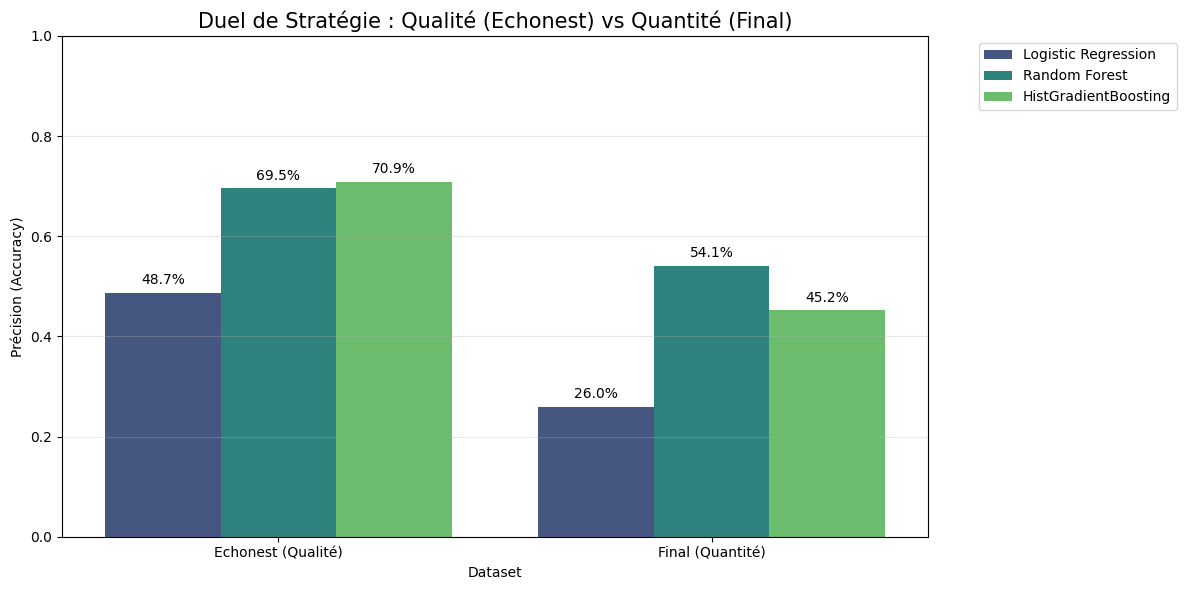


--- TABLEAU RÉCAPITULATIF ---
           Dataset               Modèle  Accuracy  Balanced Accuracy
Echonest (Qualité) HistGradientBoosting  0.709068           0.502678
Echonest (Qualité)        Random Forest  0.695214           0.393093
  Final (Quantité)        Random Forest  0.540517           0.233931
Echonest (Qualité)  Logistic Regression  0.487406           0.537394
  Final (Quantité) HistGradientBoosting  0.451806           0.309103
  Final (Quantité)  Logistic Regression  0.259881           0.313944


In [32]:
# Dictionnaire pour stocker tous les résultats
all_results = []

def entrainer_et_evaluer(X_train, y_train, X_test, y_test, nom_dataset):
    print(f"\n{'='*10} RÉSULTATS POUR : {nom_dataset} {'='*10}")
    
    # --- Définition des Modèles ---
    models = {
        # 1. Baseline Simple (Régression Logistique)
        # On met un Imputer (remplace NaN par moyenne) au cas où, et un Scaler
        "Logistic Regression": make_pipeline(
            SimpleImputer(strategy='mean'), 
            StandardScaler(), 
            LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        ),
        
        # 2. Le Classique (Random Forest)
        # Nécessite un Imputer pour les NaNs
        "Random Forest": make_pipeline(
            SimpleImputer(strategy='mean'),
            RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        ),
        
        # 3. Le Moderne (Histogram Gradient Boosting - style LightGBM)
        # Gère les NaNs NATIVEMENT (pas besoin d'imputer), très rapide
        "HistGradientBoosting": HistGradientBoostingClassifier(
            learning_rate=0.1, max_iter=100, random_state=42, class_weight='balanced'
        )
    }

    scores = {}
    
    for name, model in models.items():
        print(f"⏳ Entraînement de {name}...", end=" ")
        try:
            # Train
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Score
            acc = accuracy_score(y_test, y_pred)
            bal_acc = balanced_accuracy_score(y_test, y_pred)
            
            scores[name] = acc
            
            # Stockage pour le graphique final
            all_results.append({
                'Dataset': nom_dataset,
                'Modèle': name,
                'Accuracy': acc,
                'Balanced Accuracy': bal_acc
            })
            
            print(f"✅ OK ! Accuracy: {acc:.2%}")
            
        except Exception as e:
            print(f"❌ Erreur : {e}")

    return scores

# --- 1. Lancer sur le Dataset ECHONEST (Petit & Propre) ---
# (Utilise les variables X_train_echo crées à l'étape précédente)
entrainer_et_evaluer(X_train_echo, y_train_echo, X_test_echo, y_test_echo, "Echonest (Qualité)")

# --- 2. Lancer sur le Dataset FINAL (Grand & Sale) ---
# (Utilise les variables X_train_final crées à l'étape précédente)
# Note : Random Forest va être un peu plus lent ici
entrainer_et_evaluer(X_train_final, y_train_final, X_test_final, y_test_final, "Final (Quantité)")


# --- 3. Comparaison Visuelle ---
results_df = pd.DataFrame(all_results)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Dataset', y='Accuracy', hue='Modèle', palette='viridis')

plt.title('Duel de Stratégie : Qualité (Echonest) vs Quantité (Final)', fontsize=15)
plt.ylabel('Précision (Accuracy)')
plt.ylim(0, 1) # L'accuracy est entre 0 et 100%
plt.grid(axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Affichage des valeurs sur les barres
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.1%}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha = 'center', va = 'center', 
                           xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# Affichage du tableau récapitulatif
print("\n--- TABLEAU RÉCAPITULATIF ---")
print(results_df.sort_values(by='Accuracy', ascending=False).to_string(index=False))